# Predicción de Éxito Comercial en Steam
**Curso:** Introducción a la Inteligencía Artificial  
**Dataset:** Steam Games from 2013 to 2023 — Kaggle  
**Profesor:** Gabriel Cabas M.

## 1. Importación de librerías y carga de datos

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [32]:
# Carga de las tres tablas
df_games      = pd.read_csv('../data/raw/games.csv')
df_categories = pd.read_csv('../data/raw/t-games-categories.csv')
df_tags       = pd.read_csv('../data/raw/t-games-tags.csv')

print('games:     ', df_games.shape)
print('categories:', df_categories.shape)
print('tags:      ', df_tags.shape)

games:      (60952, 9)
categories: (210520, 2)
tags:       (777401, 3)


In [33]:
# Vista rápida de cada tabla
display(df_games.head())
display(df_categories.head())
display(df_tags.head())

,name,release_date,price,positive,negative,app_id,min_owners,max_owners,hltb_single
0,Train Bandit,"Oct 12, 2017",0.99,53,5,655370,0,20000,NaN
1,Henosis™,"Jul 23, 2020",5.99,3,0,1355720,0,20000,NaN
2,Two Weeks in Painland,"Feb 3, 2020",0.00,50,8,1139950,0,20000,NaN
3,Wartune Reborn,"Feb 26, 2021",0.00,87,49,1469160,50000,100000,NaN
4,TD Worlds,"Jan 9, 2022",10.99,21,7,1659180,0,20000,NaN


,app_id,categories
0,655370,Single-player
1,655370,Steam Achievements
2,655370,Full controller support
3,655370,Steam Leaderboards
4,655370,Remote Play on Phone


,app_id,tags,tag_frequencies
0,655370,Indie,109
1,655370,Action,103
2,655370,Pixel Graphics,100
3,655370,2D,97
4,655370,Retro,93


## 2. Análisis Exploratorio de Datos (EDA)

In [34]:
# Información general y valores nulos
df_games.info()
print('\nValores nulos:')
print(df_games.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 60952 entries, 0 to 60951
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          60952 non-null  str    
 1   release_date  60952 non-null  str    
 2   price         60952 non-null  float64
 3   positive      60952 non-null  int64  
 4   negative      60952 non-null  int64  
 5   app_id        60952 non-null  int64  
 6   min_owners    60952 non-null  int64  
 7   max_owners    60952 non-null  int64  
 8   hltb_single   12972 non-null  float64
dtypes: float64(2), int64(5), str(2)
memory usage: 4.2 MB

Valores nulos:
name                0
release_date        0
price               0
positive            0
negative            0
app_id              0
min_owners          0
max_owners          0
hltb_single     47980
dtype: int64


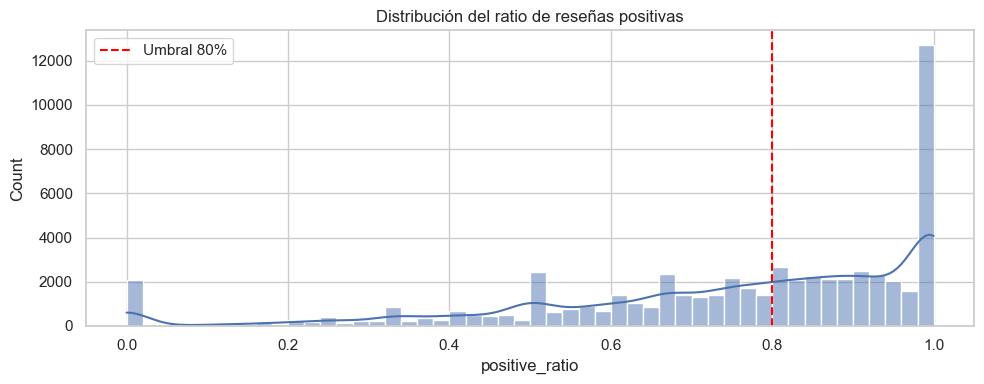

Balance de clases:
is_successful
1    0.53
0    0.47
Name: proportion, dtype: float64


In [35]:
# Construcción de la variable objetivo y revisión de balance de clases
df_games['positive_ratio'] = df_games['positive'] / (df_games['positive'] + df_games['negative'])
df_games['is_successful'] = (df_games['positive_ratio'] >= 0.80).astype(int)

plt.figure(figsize=(10, 4))
sns.histplot(data=df_games, x='positive_ratio', bins=50, kde=True)
plt.axvline(0.80, color='red', linestyle='--', label='Umbral 80%')
plt.title('Distribución del ratio de reseñas positivas')
plt.xlabel('positive_ratio')
plt.legend()
plt.tight_layout()
plt.show()

print('Balance de clases:')
print(df_games['is_successful'].value_counts(normalize=True).round(3))

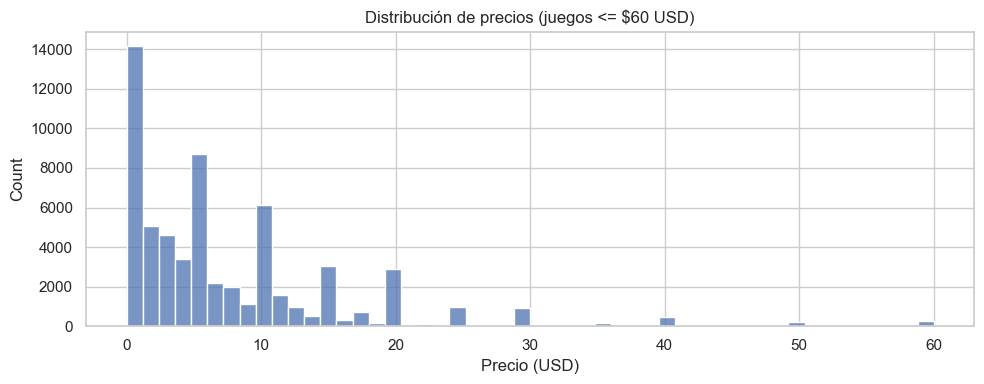

Juegos gratuitos (price = 0): 7187
Juegos > $60 USD: 116


In [36]:
# Distribución de precios
plt.figure(figsize=(10, 4))
sns.histplot(data=df_games[df_games['price'] <= 60], x='price', bins=50)
plt.title('Distribución de precios (juegos <= $60 USD)')
plt.xlabel('Precio (USD)')
plt.tight_layout()
plt.show()

print('Juegos gratuitos (price = 0):', (df_games['price'] == 0).sum())
print('Juegos > $60 USD:', (df_games['price'] > 60).sum())

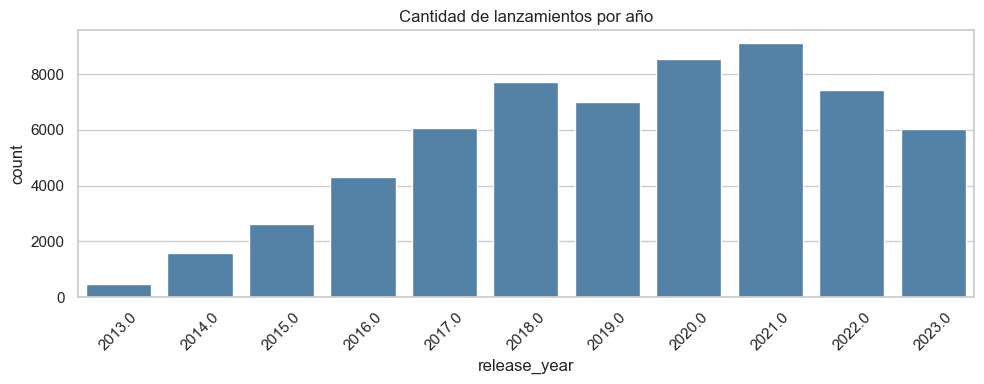

Filas sin año detectado: 100


In [37]:
# Extracción de release_year para revisar cobertura temporal
df_games['release_year'] = pd.to_datetime(df_games['release_date'], errors='coerce').dt.year

plt.figure(figsize=(10, 4))
sns.countplot(x='release_year', data=df_games, color='steelblue')
plt.title('Cantidad de lanzamientos por año')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Filas sin año detectado:', df_games['release_year'].isnull().sum())

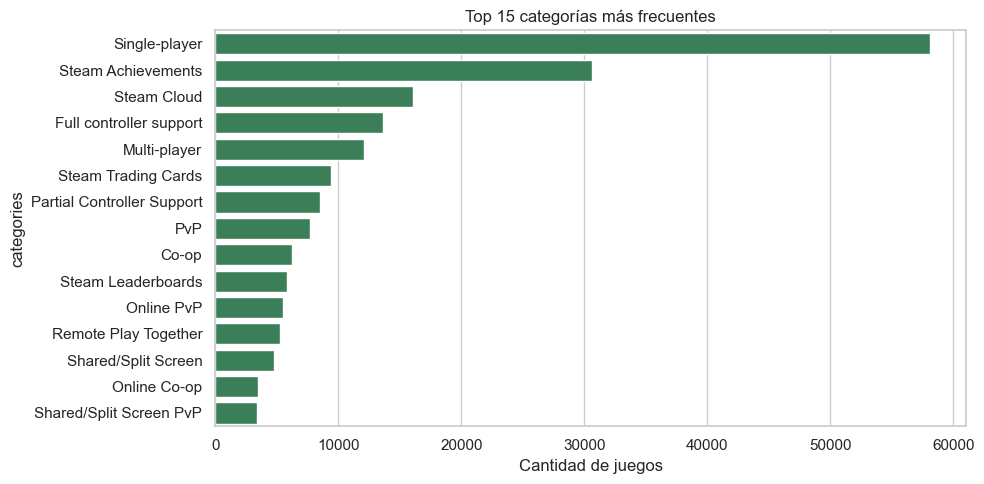

In [44]:
# Categorías más frecuentes
top_categories = (
    df_categories['categories']
    .value_counts()
    .head(15)
    .rename_axis('categories')
    .reset_index(name='count')
)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_categories, x='count', y='categories', color='seagreen')
plt.title('Top 15 categorías más frecuentes')
plt.xlabel('Cantidad de juegos')
plt.tight_layout()
plt.show()

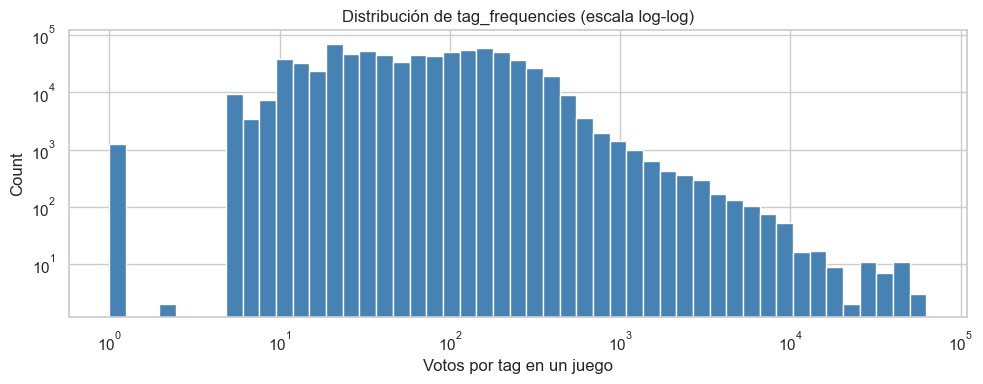

Percentiles de tag_frequencies:
count    777401.000000
mean        118.540383
std         350.977533
min           1.000000
10%          13.000000
25%          24.000000
50%          64.000000
75%         153.000000
90%         258.000000
95%         349.000000
max       62902.000000
Name: tag_frequencies, dtype: float64

Filas conservadas según umbral de corte:
  >=   1:  777401 filas (100.0%)
  >=   5:  776138 filas (99.8%)
  >=  10:  755794 filas (97.2%)
  >=  20:  655412 filas (84.3%)
  >=  50:  433713 filas (55.8%)


In [39]:
# Distribución de tag_frequencies, para definir el umbral de filtrado
bin_edges = np.logspace(
    np.log10(df_tags['tag_frequencies'].min()),
    np.log10(df_tags['tag_frequencies'].max()),
    50
)

plt.figure(figsize=(10, 4))
plt.hist(df_tags['tag_frequencies'], bins=bin_edges, color='steelblue', edgecolor='white')
plt.xscale('log')
plt.yscale('log')
plt.title('Distribución de tag_frequencies (escala log-log)')
plt.xlabel('Votos por tag en un juego')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print('Percentiles de tag_frequencies:')
print(df_tags['tag_frequencies'].describe(percentiles=[.10, .25, .50, .75, .90, .95]))

print()
print('Filas conservadas según umbral de corte:')
for thresh in [1, 5, 10, 20, 50]:
    n_rows = (df_tags['tag_frequencies'] >= thresh).sum()
    pct = n_rows / len(df_tags) * 100
    print(f'  >= {thresh:>3}: {n_rows:>7} filas ({pct:.1f}%)')

## 3. Limpieza de datos y Feature Engineering

### 3.1 Exclusión de variables post-lanzamiento

Como se documentó en el README, `positive` y `negative` solo se usan para construir la
variable objetivo (nunca como features), y `min_owners`, `max_owners`, `hltb_single` se
excluyen por completo: son señales que solo existen después del lanzamiento y que,
además, mostraron correlación casi nula con la variable objetivo durante el EDA.

In [40]:
# Variable objetivo y limpieza base
df_games['positive_ratio'] = df_games['positive'] / (df_games['positive'] + df_games['negative'])
df_games['is_successful'] = (df_games['positive_ratio'] >= 0.80).astype(int)
df_games['release_year'] = pd.to_datetime(df_games['release_date'], errors='coerce').dt.year

# Columnas post-lanzamiento que NUNCA se usarán como features
POST_LAUNCH_COLS = ['positive', 'negative', 'min_owners', 'max_owners', 'hltb_single']

print('Verificación: estas columnas se excluyen explícitamente del feature set ->', POST_LAUNCH_COLS)

Verificación: estas columnas se excluyen explícitamente del feature set -> ['positive', 'negative', 'min_owners', 'max_owners', 'hltb_single']


### 3.2 Procesamiento de `t-games-categories.csv`

La tabla está en formato largo (una fila por categoría asignada a un juego). Se convierte
a formato ancho mediante `pivot`, generando una columna binaria por categoría (1 si el
juego la tiene, 0 si no).

In [41]:
categories_pivot = (
    df_categories.groupby(['app_id', 'categories']).size()
    .unstack(fill_value=0)
    .clip(upper=1)
)
categories_pivot.columns = [
    'cat_' + c.lower().replace(' ', '_').replace('-', '_') for c in categories_pivot.columns
]

print('Shape categories_pivot:', categories_pivot.shape)
categories_pivot.head()

Shape categories_pivot: (60950, 35)


,cat_captions_available,cat_co_op,cat_commentary_available,cat_cross_platform_multiplayer,cat_full_controller_support,cat_in_app_purchases,cat_includes_level_editor,cat_lan_co_op,cat_lan_pvp,cat_mmo,cat_multi_player,cat_online_co_op,cat_online_pvp,cat_partial_controller_support,cat_pvp,cat_remote_play_together,cat_remote_play_on_phone,cat_remote_play_on_tv,cat_remote_play_on_tablet,cat_shared/split_screen,cat_shared/split_screen_co_op,cat_shared/split_screen_pvp,cat_single_player,cat_stats,cat_steam_achievements,cat_steam_cloud,cat_steam_leaderboards,cat_steam_trading_cards,cat_steam_turn_notifications,cat_steam_workshop,cat_tracked_controller_support,cat_vr_only,cat_vr_support,cat_vr_supported,cat_valve_anti_cheat_enabled
app_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
570,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1
1313,0,0,0,0,0,0,0,0,1,0,1,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2870,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,1,0,1,0,0,0,0,0
7800,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,1,1,0,1,0,1,1,0,1,0,0,0,0,0,0,0
8870,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,1,1,0,1,0,0,0,0,0,0,0


### 3.3 Procesamiento de `t-games-tags.csv`

Antes del pivot, se filtran las filas con `tag_frequencies` por debajo de un umbral
mínimo. Esto no reduce la cantidad de tags únicos (siguen existiendo los mismos ~405),
pero elimina asociaciones tag-juego débiles (un tag votado por muy pocos usuarios para
ese juego puntual), reduciendo ruido en la matriz de features. Se usa un umbral de 10
votos, que conserva el 97.2% de las filas según el análisis del EDA.

In [42]:
TAG_FREQ_THRESHOLD = 10

df_tags_filtered = df_tags[df_tags['tag_frequencies'] >= TAG_FREQ_THRESHOLD]

tags_pivot = (
    df_tags_filtered.groupby(['app_id', 'tags']).size()
    .unstack(fill_value=0)
    .clip(upper=1)
)
tags_pivot.columns = [
    'tag_' + t.lower().replace(' ', '_').replace('-', '_') for t in tags_pivot.columns
]

print('Shape tags_pivot:', tags_pivot.shape)
tags_pivot.head()

Shape tags_pivot: (60942, 405)


,tag_1980s,tag_1990's,tag_2.5d,tag_2d,tag_2d_fighter,tag_2d_platformer,tag_360_video,tag_3d,tag_3d_fighter,tag_3d_platformer,tag_3d_vision,tag_4_player_local,tag_4x,tag_6dof,tag_abstract,tag_action,tag_action_rpg,tag_action_rts,tag_action_roguelike,tag_action_adventure,tag_addictive,tag_adventure,tag_agriculture,tag_aliens,tag_alternate_history,tag_ambient,tag_america,tag_animation_&_modeling,tag_anime,tag_arcade,tag_archery,tag_arena_shooter,tag_artificial_intelligence,tag_assassin,tag_asymmetric_vr,tag_asynchronous_multiplayer,tag_atmospheric,tag_audio_production,tag_auto_battler,tag_automation,tag_automobile_sim,tag_base_building,tag_baseball,tag_based_on_a_novel,tag_basketball,tag_battle_royale,tag_beat_'em_up,tag_beautiful,tag_bikes,tag_blood,tag_board_game,tag_boxing,tag_building,tag_bullet_hell,tag_bullet_time,tag_crpg,tag_capitalism,tag_card_battler,tag_card_game,tag_cartoon,tag_cartoony,tag_casual,tag_cats,tag_character_action_game,tag_character_customization,tag_chess,tag_choices_matter,tag_choose_your_own_adventure,tag_cinematic,tag_city_builder,tag_class_based,tag_classic,tag_clicker,tag_co_op,tag_co_op_campaign,tag_cold_war,tag_collectathon,tag_colony_sim,tag_colorful,tag_combat,tag_combat_racing,tag_comedy,tag_comic_book,tag_competitive,tag_conspiracy,tag_controller,tag_conversation,tag_cooking,tag_cozy,tag_crafting,tag_creature_collector,tag_crime,tag_crowdfunded,tag_cult_classic,tag_cute,tag_cyberpunk,tag_cycling,tag_dark,tag_dark_comedy,tag_dark_fantasy,tag_dark_humor,tag_dating_sim,tag_deckbuilding,tag_demons,tag_design_&_illustration,tag_destruction,tag_detective,tag_difficult,tag_dinosaurs,tag_diplomacy,tag_dog,tag_dragons,tag_drama,tag_driving,tag_dungeon_crawler,tag_dungeons_&_dragons,tag_dynamic_narration,tag_dystopian_,tag_early_access,tag_economy,tag_education,tag_electronic_music,tag_emotional,tag_epic,tag_episodic,tag_escape_room,tag_experience,tag_experimental,tag_exploration,tag_fmv,tag_fps,tag_faith,tag_family_friendly,tag_fantasy,tag_farming,tag_farming_sim,tag_fast_paced,tag_female_protagonist,tag_fighting,tag_first_person,tag_fishing,tag_flight,tag_football,tag_foreign,tag_free_to_play,tag_funny,tag_futuristic,tag_gambling,tag_game_development,tag_gamemaker,tag_games_workshop,tag_gaming,tag_god_game,tag_golf,tag_gore,tag_gothic,tag_grand_strategy,tag_great_soundtrack,tag_grid_based_movement,tag_gun_customization,tag_hack_and_slash,tag_hacking,tag_hand_drawn,tag_heist,tag_hentai,tag_hero_shooter,tag_hex_grid,tag_hidden_object,tag_historical,tag_horror,tag_horses,tag_hunting,tag_idler,tag_illuminati,tag_immersive,tag_immersive_sim,tag_indie,tag_intentionally_awkward_controls,tag_interactive_fiction,tag_inventory_management,tag_investigation,tag_isometric,tag_jrpg,tag_jet,tag_kickstarter,tag_lego,tag_lgbtq+,tag_lemmings,tag_level_editor,tag_life_sim,tag_linear,tag_local_co_op,tag_local_multiplayer,tag_logic,tag_loot,tag_looter_shooter,tag_lore_rich,tag_lovecraftian,tag_mmorpg,tag_moba,tag_magic,tag_management,tag_mars,tag_martial_arts,tag_massively_multiplayer,tag_match_3,tag_mature,tag_mechs,tag_medical_sim,tag_medieval,tag_memes,tag_metroidvania,tag_military,tag_mini_golf,tag_minigames,tag_minimalist,tag_mining,tag_mod,tag_moddable,tag_modern,tag_motocross,tag_motorbike,tag_mouse_only,tag_movie,tag_multiplayer,tag_multiple_endings,tag_music,tag_music_based_procedural_generation,tag_mystery,tag_mystery_dungeon,tag_mythology,tag_nsfw,tag_narration,tag_narrative,tag_nature,tag_naval,tag_naval_combat,tag_ninja,tag_noir,tag_nonlinear,tag_nostalgia,tag_nudity,tag_offroad,tag_old_school,tag_on_rails_shooter,tag_online_co_op,tag_open_world,tag_open_world_survival_craft,tag_otome,tag_outbreak_sim,tag_parkour,tag_parody_,tag_party,tag_party_game,tag_party_based_rpg,tag_perma_death,tag_philosophical,tag_physics,tag_pinball,tag_pirates,tag_pixel_graphics,tag_platformer,tag_point_&_click,tag_political,tag_political_sim,tag_politics,tag_pool,tag_post_apocalyptic,tag_precision_platformer,tag_procedural_generat

### 3.4 Unión de las tres tablas

Se integran `games`, `categories_pivot` y `tags_pivot` mediante `app_id`, usando
`how='left'` para conservar todos los juegos aunque no tengan categorías o tags
registrados (en ese caso, sus columnas binarias quedan en 0 tras el `fillna`).

In [43]:
df = (
    df_games.set_index('app_id')
    .merge(categories_pivot, left_index=True, right_index=True, how='left')
    .merge(tags_pivot, left_index=True, right_index=True, how='left')
)

bin_cols = [c for c in df.columns if c.startswith('cat_') or c.startswith('tag_')]
df[bin_cols] = df[bin_cols].fillna(0).astype(int)

print('Shape final del dataset integrado:', df.shape)
print('Juegos sin ninguna categoría/tag tras el left join:', df[bin_cols].sum(axis=1).eq(0).sum())
df.head()

Shape final del dataset integrado: (60952, 451)
Juegos sin ninguna categoría/tag tras el left join: 0


,name,release_date,price,positive,negative,min_owners,max_owners,hltb_single,positive_ratio,is_successful,release_year,cat_captions_available,cat_co_op,cat_commentary_available,cat_cross_platform_multiplayer,cat_full_controller_support,cat_in_app_purchases,cat_includes_level_editor,cat_lan_co_op,cat_lan_pvp,cat_mmo,cat_multi_player,cat_online_co_op,cat_online_pvp,cat_partial_controller_support,cat_pvp,cat_remote_play_together,cat_remote_play_on_phone,cat_remote_play_on_tv,cat_remote_play_on_tablet,cat_shared/split_screen,cat_shared/split_screen_co_op,cat_shared/split_screen_pvp,cat_single_player,cat_stats,cat_steam_achievements,cat_steam_cloud,cat_steam_leaderboards,cat_steam_trading_cards,cat_steam_turn_notifications,cat_steam_workshop,cat_tracked_controller_support,cat_vr_only,cat_vr_support,cat_vr_supported,cat_valve_anti_cheat_enabled,tag_1980s,tag_1990's,tag_2.5d,tag_2d,tag_2d_fighter,tag_2d_platformer,tag_360_video,tag_3d,tag_3d_fighter,tag_3d_platformer,tag_3d_vision,tag_4_player_local,tag_4x,tag_6dof,tag_abstract,tag_action,tag_action_rpg,tag_action_rts,tag_action_roguelike,tag_action_adventure,tag_addictive,tag_adventure,tag_agriculture,tag_aliens,tag_alternate_history,tag_ambient,tag_america,tag_animation_&_modeling,tag_anime,tag_arcade,tag_archery,tag_arena_shooter,tag_artificial_intelligence,tag_assassin,tag_asymmetric_vr,tag_asynchronous_multiplayer,tag_atmospheric,tag_audio_production,tag_auto_battler,tag_automation,tag_automobile_sim,tag_base_building,tag_baseball,tag_based_on_a_novel,tag_basketball,tag_battle_royale,tag_beat_'em_up,tag_beautiful,tag_bikes,tag_blood,tag_board_game,tag_boxing,tag_building,tag_bullet_hell,tag_bullet_time,tag_crpg,tag_capitalism,tag_card_battler,tag_card_game,tag_cartoon,tag_cartoony,tag_casual,tag_cats,tag_character_action_game,tag_character_customization,tag_chess,tag_choices_matter,tag_choose_your_own_adventure,tag_cinematic,tag_city_builder,tag_class_based,tag_classic,tag_clicker,tag_co_op,tag_co_op_campaign,tag_cold_war,tag_collectathon,tag_colony_sim,tag_colorful,tag_combat,tag_combat_racing,tag_comedy,tag_comic_book,tag_competitive,tag_conspiracy,tag_controller,tag_conversation,tag_cooking,tag_cozy,tag_crafting,tag_creature_collector,tag_crime,tag_crowdfunded,tag_cult_classic,tag_cute,tag_cyberpunk,tag_cycling,tag_dark,tag_dark_comedy,tag_dark_fantasy,tag_dark_humor,tag_dating_sim,tag_deckbuilding,tag_demons,tag_design_&_illustration,tag_destruction,tag_detective,tag_difficult,tag_dinosaurs,tag_diplomacy,tag_dog,tag_dragons,tag_drama,tag_driving,tag_dungeon_crawler,tag_dungeons_&_dragons,tag_dynamic_narration,tag_dystopian_,tag_early_access,tag_economy,tag_education,tag_electronic_music,tag_emotional,tag_epic,tag_episodic,tag_escape_room,tag_experience,tag_experimental,tag_exploration,tag_fmv,tag_fps,tag_faith,tag_family_friendly,tag_fantasy,tag_farming,tag_farming_sim,tag_fast_paced,tag_female_protagonist,tag_fighting,tag_first_person,tag_fishing,tag_flight,tag_football,tag_foreign,tag_free_to_play,tag_funny,tag_futuristic,tag_gambling,tag_game_development,tag_gamemaker,tag_games_workshop,tag_gaming,tag_god_game,tag_golf,tag_gore,tag_gothic,tag_grand_strategy,tag_great_soundtrack,tag_grid_based_movement,tag_gun_customization,tag_hack_and_slash,tag_hacking,tag_hand_drawn,tag_heist,tag_hentai,tag_hero_shooter,tag_hex_grid,tag_hidden_object,tag_historical,tag_horror,tag_horses,tag_hunting,tag_idler,tag_illuminati,tag_immersive,tag_immersive_sim,tag_indie,tag_intentionally_awkward_controls,tag_interactive_fiction,tag_inventory_management,tag_investigation,tag_isometric,tag_jrpg,tag_jet,tag_kickstarter,tag_lego,tag_lgbtq+,tag_lemmings,tag_level_editor,tag_life_sim,tag_linear,tag_local_co_op,tag_local_multiplayer,tag_logic,tag_loot,tag_looter_shooter,tag_lore_rich,tag_lovecraftian,tag_mmorpg,tag_moba,tag_magic,tag_management,tag_mars,tag_martial_arts,tag_massively_multiplayer,tag_match_3,tag_mature,tag_mechs,tag_medical_sim,tag_medieval,tag_memes,tag_metroidvania,tag_military,tag

## 4. Selección de variables (Feature Selection)

## 5. Entrenamiento del modelo

## 6. Control de overfitting (validación cruzada)

## 7. Evaluación y reporte de resultados